# Comparison: CS-01 TAS

**Purpose**: cross-method R1 / R2 triangulation, then place the DASA-guided search winner alongside the four hand-authored adaptations. Reads the persisted analytic, stochastic, and dimensional result envelopes (plus the search winner) from disk and renders the convergence + numerical agreement bands that close the CS-1 model-only chapter. Internal consistency across three independent predictive pipelines is the chapter's bottom-line claim; external falsification is deferred to the PACS prototype fork.

**Inputs**:
- `data/results/{analytic,stochastic,dimensional}/<adp>/<profile>.json` -- per-method `network` + `nodes` envelopes (shared shape after the 2026-06-15 dimensional symmetrisation).
- `data/results/{analytic,stochastic,dimensional}/<adp>/requirements.json` -- per-method R1 / R2 verdict with per-node `contributions`.
- `data/results/dimensional/winner/{search,requirements}.json` + `data/results/search/winner/winner.json` -- the search winner (network + verdict + retry + scipy cross-check), written by `05-search.ipynb`.
- `data/reference/baseline.json` -- shared R1 / R2 thresholds.

**Outputs**:
- `data/img/comparison/<adp>/verdict_grid.{png,svg}` -- cross-method PASS / FAIL grid with delta-vs-baseline cell tint.
- `data/img/comparison/metrics_bars.{png,svg}` -- W_e2e and eps_e2e grouped bars across all five solutions (the four adaptations + the search winner), three method bars per group (section 4).
- Tabular outputs render inline (verdict matrix + numerical agreement + per-node contributor side-by-side + winner configuration + numeric solution table).

**Equivalent CLI**: none -- this notebook is read-only. Re-running the three method modules refreshes the cross-method inputs; re-running `05-search.ipynb` refreshes the winner:

```bash
python -m src.methods.analytic    --adaptation {baseline,s1,s2,aggregate}
python -m src.methods.stochastic  --adaptation {baseline,s1,s2,aggregate}
python -m src.methods.dimensional --adaptation {baseline,s1,s2,aggregate}
```

This notebook is thin: all logic lives in `src.io.results` (`load_qn_result`, `load_requirements`) and `src.view.diagrams` (`plot_verdict_grid`, `plot_method_metric_bars`). The cells below orchestrate the load, build the verdict matrix, render the headline grid, surface the per-method contribution evidence, and compare the search winner against the published adaptations.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd
import json   # as _json


from src.io.results import load_qn_result, load_requirements
from src.view import plot_verdict_grid
from src.view import plot_method_metric_bars


# axes of comparison: three methods x four adaptations x two requirements
METHODS = ["analytic", "stochastic", "dimensional"]
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]
REQUIREMENTS = ["R1", "R2"]

# figure output root for this method
IMG_ROOT = Path("data/img/comparison")

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

## 1. Load every (method, adaptation)

`load_qn_result(method, adp)` reads the per-method `network` + `nodes` envelope; `load_requirements(method, adp)` reads the R1 / R2 verdict with per-node contributions. Twelve (3 methods x 4 adaptations) pairs in total.

In [2]:
results = {
    m: {
        a: load_qn_result(m, a) for a in ADAPTATIONS
    } for m in METHODS
}
reqs = {
    m: {
        a: load_requirements(m, a) for a in ADAPTATIONS
    } for m in METHODS
}

# per-method per-adaptation network frames (single-row), keyed for downstream cells
nets = {
    m: {
        a: pd.DataFrame([results[m][a]["network"]]) for a in ADAPTATIONS
    } for m in METHODS
}

# the DASA-guided search winner (05-search.ipynb), loaded as a 5th solution
WINNER_DIR = Path("data/results/dimensional/winner")
SEARCH_WINNER_DIR = Path("data/results/search/winner")

winner_net = json.loads((WINNER_DIR / "search.json").read_text(encoding="utf-8"))["network"]
winner_req = json.loads((WINNER_DIR / "requirements.json").read_text(encoding="utf-8"))
winner_meta = json.loads((SEARCH_WINNER_DIR / "winner.json").read_text(encoding="utf-8"))

# the winner is one configuration evaluated by the dimensional pipeline (analytic-equivalent);
# expose it under every method so it slots into the section-3 grid + section-4 bars as a 5th column
winner_df = pd.DataFrame([winner_net])
for m in METHODS:
    nets[m]["winner"] = winner_df
    reqs[m]["winner"] = winner_req
SOLUTIONS = ADAPTATIONS + ["winner"]

print(f"Loaded {len(METHODS)} methods x {len(ADAPTATIONS)} adaptations + the search winner")

Loaded 3 methods x 4 adaptations + the search winner


## 2. Verdict matrix + congruence check

One row per adaptation. The six PASS / FAIL columns split into `R1.<method>` and `R2.<method>`. The `R1 congruent` and `R2 congruent` columns report whether all three methods agree on that adaptation x requirement cell (the dissertation's bottom-line claim is that every cell is congruent).

In [3]:
matrix_rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    for r in REQUIREMENTS:
        passes = []
        for m in METHODS:
            v = reqs[m][a][r]
            if v["pass"]:
                row[f"{r}.{m}"] = "PASS"
                passes.append(True)
            else:
                row[f"{r}.{m}"] = "FAIL"
                passes.append(False)
        if all(p == passes[0] for p in passes):
            row[f"{r} congruent"] = "YES"
        else:
            row[f"{r} congruent"] = "NO"
    matrix_rows.append(row)
verdict_df = pd.DataFrame(matrix_rows).set_index("adaptation")
verdict_df

,R1.analytic,R1.stochastic,R1.dimensional,R1 congruent,R2.analytic,R2.stochastic,R2.dimensional,R2 congruent
adaptation,,,,,,,,
baseline,FAIL,FAIL,FAIL,YES,PASS,PASS,PASS,YES
s1,PASS,PASS,PASS,YES,FAIL,FAIL,FAIL,YES
s2,FAIL,FAIL,FAIL,YES,PASS,PASS,PASS,YES
aggregate,PASS,PASS,PASS,YES,PASS,PASS,PASS,YES


## 3. Headline verdict grid

Cross-method PASS / FAIL grid with the four published adaptations plus the search winner in one figure. Cell tint follows the project's neutral delta palette:

- blue cell -> decrease vs baseline (improvement on a `<= threshold` metric)
- near-white cell -> baseline (reference)
- orange cell -> increase vs baseline (degradation)

Inside each cell, PASS (green bold italic) / FAIL (red bold italic) reports the threshold verdict; the bare number below is the scaled value (ms for R2, % for R1; units live on the panel title so cells stay compact). The search winner is one configuration evaluated once by the dimensional pipeline, so its three method cells coincide.

The figure is saved to `data/img/comparison/verdict_grid.{png,svg}`.

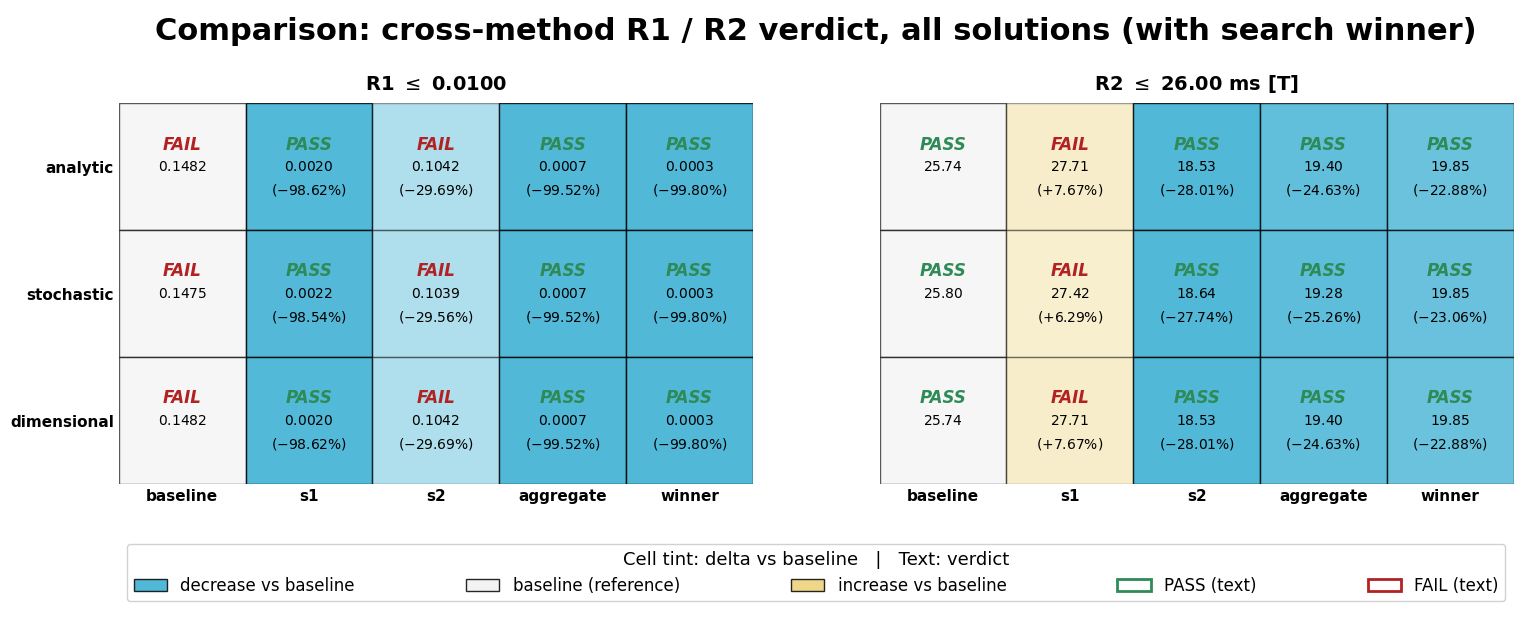

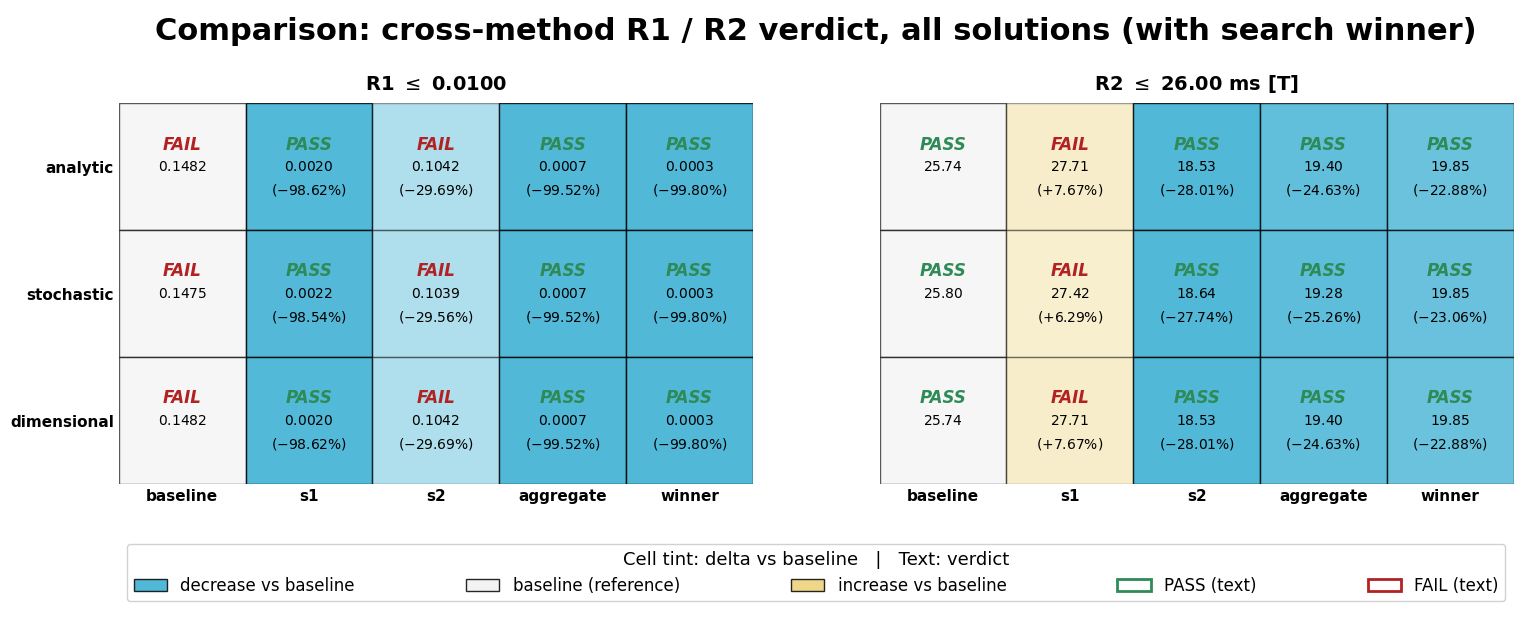

In [4]:
plot_verdict_grid(reqs,
                  methods=METHODS,
                  adaptations=SOLUTIONS,
                  requirements=REQUIREMENTS,
                  title="Comparison: cross-method R1 / R2 verdict, all solutions (with search winner)",
                  file_path=str(IMG_ROOT),
                  fname="verdict_grid")

## 4. Cross-solution bar chart: $W_{e2e}$ and $\varepsilon_{e2e}$

One panel per requirement. Within each panel, five solution groups on the x-axis (the four published adaptations plus the search winner); three within-group bars (analytic / stochastic / dimensional). The dashed red line marks the R1 / R2 threshold.

Within each adaptation group the three bars sit at nearly the same height: analytic and dimensional are identical by construction (the dimensional method reads its $W_{e2e}$ and $\varepsilon_{e2e}$ from the same Jackson solve as analytic) and stochastic differs only by DES Monte-Carlo noise. The **search winner** is one configuration evaluated once by the dimensional pipeline, so its three bars coincide; it is shown here to place it directly against the published solutions.

The figure is saved to `data/img/comparison/metrics_bars.{png,svg}`.

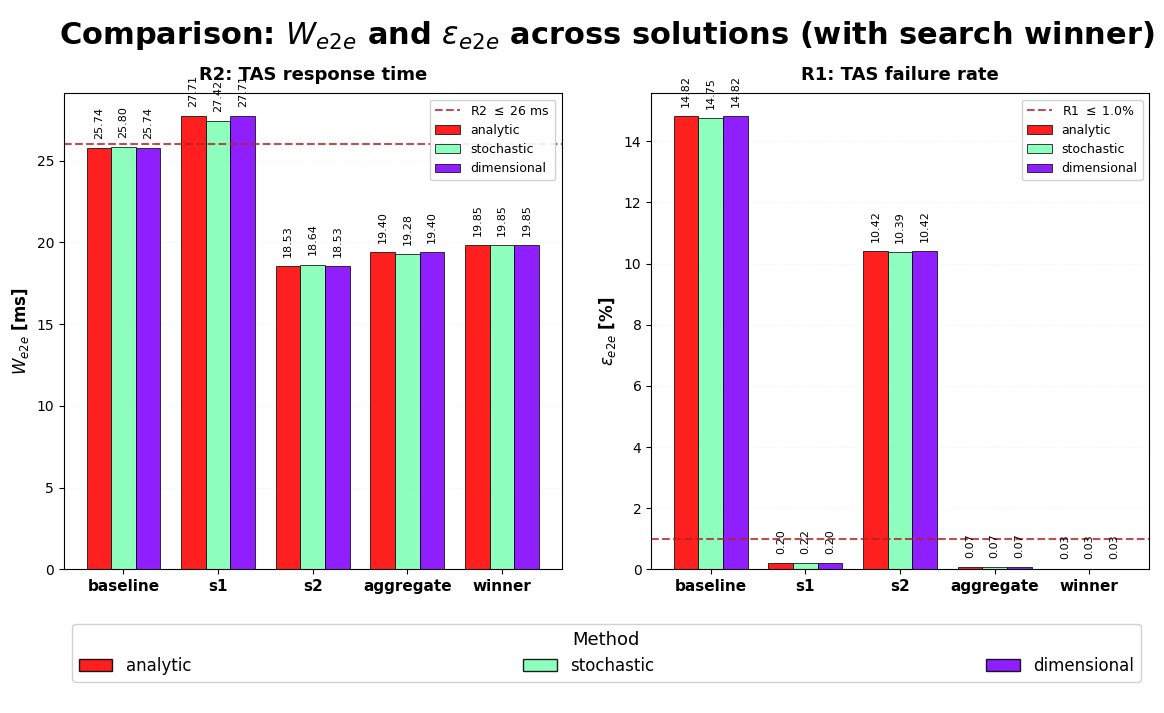

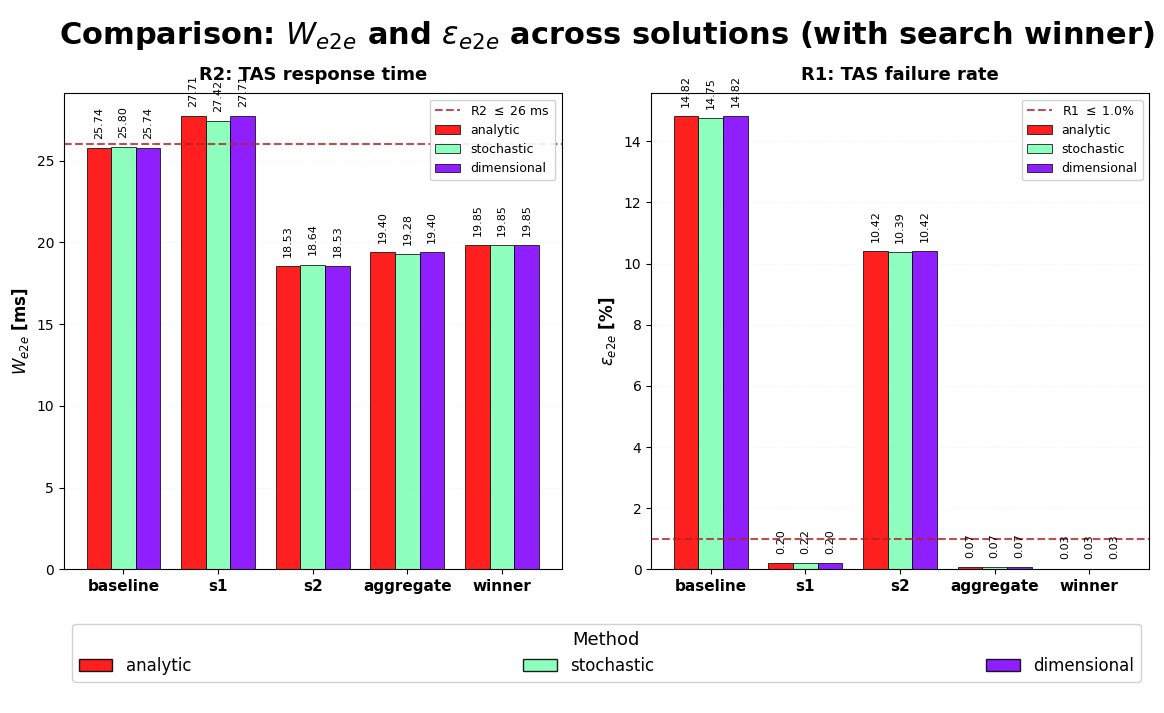

In [5]:
W_R2 = reqs["analytic"]["baseline"]["R2"]["threshold"]   # seconds
EPS_R1 = reqs["analytic"]["baseline"]["R1"]["threshold"]   # fraction

plot_method_metric_bars(
    nets,
    methods=METHODS,
    adaptations=SOLUTIONS,
    metrics=["W_e2e", "eps_e2e"],
    scales=[1000.0, 100.0],
    panel_titles=[
        "R2: TAS response time",
        "R1: TAS failure rate",
    ],
    ylabels=[r"$W_{e2e}$ [ms]", r"$\varepsilon_{e2e}$ [%]"],
    thresholds=[W_R2, EPS_R1],
    threshold_labels=[
        rf"R2 $\leq$ {W_R2*1000:.0f} ms",
        rf"R1 $\leq$ {EPS_R1*100:.1f}%",
    ],
    title=r"Comparison: $W_{e2e}$ and $\varepsilon_{e2e}$ across solutions (with search winner)",
    file_path=str(IMG_ROOT),
    fname="metrics_bars",
)

## 5. Per-node analytic-vs-stochastic agreement (cross-reference)

The aggregate-level cross-method agreement shown in §3 and §4 rests on a per-node match between the analytic closed-form solution and the stochastic SimPy DES simulation. Each node's $\rho$, $L$, and $W$ must lie within the DES Monte-Carlo confidence interval; if any per-node mean drifts outside the band, the aggregate $W_{e2e}$ / $\varepsilon_{e2e}$ agreement in §4 is incidental rather than principled.

The per-node confidence-interval bands plus the analytic-baseline overlay live in [`02-stochastic.ipynb` §6](02-stochastic.ipynb): 95% CI error bars from `_std` columns, computed at $z \cdot \sigma / \sqrt{n_{\text{reps}}}$, with the analytic closed-form value as a red marker. For the locked envelope ($\lambda_z = 323$ req/s, 10 DES reps × 10000 invocations) every node's analytic point falls inside the stochastic CI band, which is the empirical justification for the $\sim 4\%$ aggregate $W_{e2e}$ agreement reported in §4.

No duplicate plot here; this section is the cross-reference. The dissertation chapter cites both notebooks together: §3 / §4 of `06-comparison.ipynb` for the cross-method aggregate verdict; §6 of `02-stochastic.ipynb` for the per-node empirical-vs-closed-form check.

## 6. Numerical agreement table (analytic vs stochastic)

Per-adaptation deltas between analytic (closed-form) and stochastic (SimPy DES) predictions. The dimensional pipeline is identical to analytic by construction (it reads the same Jackson solve) and is reported as a row in the verdict grid + bars; the meaningful method-to-method noise lives between analytic and stochastic.

Bounds the dissertation can quote:

- $\Delta W_{e2e}$ : absolute (ms) and relative (%). Relative agreement bounds the Monte-Carlo noise on the per-request end-to-end response time across all four adaptations.
- $\Delta \varepsilon_{e2e}$ : in percentage points (pp). Relative pp on the end-to-end failure rate (flow leaked to the $\mathrm{FAIL}_1$ sink, $\varepsilon_{e2e} = \lambda_{\mathrm{FAIL}}/\lambda_z$).

Both deltas use $\text{stochastic} - \text{analytic}$ so positive means stochastic over-predicts.

In [6]:
agrt_rows = []
for a in ADAPTATIONS:
    w_a = float(nets["analytic"][a].iloc[0]["W_e2e"])
    w_s = float(nets["stochastic"][a].iloc[0]["W_e2e"])
    e_a = float(nets["analytic"][a].iloc[0]["eps_e2e"])
    e_s = float(nets["stochastic"][a].iloc[0]["eps_e2e"])
    dw = w_s - w_a
    de = e_s - e_a
    if w_a > 0:
        dw_pct = dw / w_a * 100.0
    else:
        dw_pct = float("nan")
    agrt_rows.append({
        "adaptation": a,
        r"$W_{e2e}$ analytic [ms]": w_a * 1000,
        r"$W_{e2e}$ stochastic [ms]":  w_s * 1000,
        r"$\Delta W_{e2e}$ [ms]": dw * 1000,
        r"$\Delta W_{e2e}$ [%]": dw_pct,
        r"$\varepsilon_{e2e}$ analytic [%]": e_a * 100,
        r"$\varepsilon_{e2e}$ stochastic [%]": e_s * 100,
        r"$\Delta \varepsilon_{e2e}$ [pp]": de * 100,
    })
agreed_df = pd.DataFrame(agrt_rows).set_index("adaptation")
agreed_df.round(3)

,$W_{e2e}$ analytic [ms],$W_{e2e}$ stochastic [ms],$\Delta W_{e2e}$ [ms],$\Delta W_{e2e}$ [%],$\varepsilon_{e2e}$ analytic [%],$\varepsilon_{e2e}$ stochastic [%],$\Delta \varepsilon_{e2e}$ [pp]
adaptation,,,,,,,
baseline,25.740,25.799,0.059,0.229,14.822,14.748,-0.074
s1,27.715,27.421,-0.293,-1.058,0.205,0.216,0.011
s2,18.529,18.642,0.113,0.608,10.422,10.388,-0.034
aggregate,19.401,19.281,-0.120,-0.620,0.071,0.071,-0.000


## 7. Per-node top contributors per requirement, side-by-side

For each adaptation, the verdict modules' `contributions` list ranks per-node drivers of the R1 (failure rate) and R2 (response time) totals. Showing the top-1 contributor per method side-by-side lets the dissertation argue that all three pipelines flag the same bottleneck node, not merely the same aggregate number.

For R1: each contributor reports the node, its $\varepsilon_j$, its visit ratio $V_j$, and its share of the end-to-end failure (the flow that node leaks into the $\mathrm{FAIL}_1$ sink as a fraction of $\lambda_z$); the per-node shares sum to $\varepsilon_{e2e}$.

For R2: each contributor reports the node, its $L_j$ and $W_j$, and its share $L_j / L_{net}$ of the end-to-end response time.

Identical top-node identification across methods is the chapter's "the dimensional method does not invent a new bottleneck" claim.

In [7]:
def _r1_top_str(v: dict) -> str:
    """_r1_top_str format the top R1 contributor for a given method-adaptation result contributor dict into a human-readable string for display in the agreement table.

    Args:
        v (dict): a method-adaptation result contributor dict containing a "contributions" list of dicts with keys "node", "epsilon", "V", and "contribution".

    Returns:
        str: a human-readable string summarising the top R1 contributor, or "-" if there are no contributors.
    """
    contribs = v.get("contributions", [])
    msg = "-"
    if contribs:
        c = contribs[0]
        msg = f"{c['node']} (eps={c['epsilon']:.2f}, V={c['V']:.3f}, {c['contribution']*100:.2f}%)"
    return msg


def _r2_top_str(v: dict) -> str:
    """_r2_top_str format the top R2 contributor for a given method-adaptation result contributor dict into a human-readable string for display in the agreement table.

    Args:
        v (dict): a method-adaptation result contributor dict containing a "contributions" list of dicts with keys "node", "L", "W", and "share".

    Returns:
        str: a human-readable string summarising the top R2 contributor, or "-" if there are no contributors.
    """
    contribs = v.get("contributions", [])
    msg = "-"
    if contribs:
        c = contribs[0]
        msg = f"{c['node']} (L={c['L']:.2f}, W={c['W']*1000:.2f} ms, share={c['share']*100:.1f}%)"
    return msg

In [8]:
contrib_rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    for m in METHODS:
        row[f"R1 top.{m}"] = _r1_top_str(reqs[m][a]["R1"])
    for m in METHODS:
        row[f"R2 top.{m}"] = _r2_top_str(reqs[m][a]["R2"])
    contrib_rows.append(row)

contrib_df = pd.DataFrame(contrib_rows).set_index("adaptation")
with pd.option_context("display.max_colwidth", None):
    display(contrib_df)

,R1 top.analytic,R1 top.stochastic,R1 top.dimensional,R2 top.analytic,R2 top.stochastic,R2 top.dimensional
adaptation,,,,,,
baseline,"TAS_{4} (eps=0.12, V=0.750, 9.21%)","TAS_{4} (eps=0.12, V=0.749, 9.20%)","TAS_{4} (eps=0.12, V=0.750, 9.21%)","MAS_{3} (L=1.85, W=18.94 ms, share=26.1%)","MAS_{3} (L=1.87, W=19.13 ms, share=26.3%)","MAS_{3} (L=1.85, W=18.94 ms, share=26.1%)"
s1,"TAS_{4} (eps=0.00, V=0.853, 0.14%)","TAS_{4} (eps=0.00, V=0.855, 0.14%)","TAS_{4} (eps=0.00, V=0.853, 0.14%)","MAS_{3} (L=2.47, W=23.01 ms, share=28.5%)","MAS_{3} (L=2.31, W=21.70 ms, share=27.0%)","MAS_{3} (L=2.47, W=23.01 ms, share=28.5%)"
s2,"TAS_{4} (eps=0.09, V=0.750, 6.89%)","TAS_{4} (eps=0.09, V=0.751, 6.89%)","TAS_{4} (eps=0.09, V=0.750, 6.89%)","DS_{1} (L=1.32, W=9.26 ms, share=25.3%)","DS_{1} (L=1.32, W=9.27 ms, share=25.3%)","DS_{1} (L=1.32, W=9.26 ms, share=25.3%)"
aggregate,"TAS_{4} (eps=0.00, V=0.825, 0.06%)","TAS_{4} (eps=0.00, V=0.823, 0.06%)","TAS_{4} (eps=0.00, V=0.825, 0.06%)","DS_{1} (L=1.71, W=10.82 ms, share=28.2%)","DS_{1} (L=1.69, W=10.76 ms, share=28.1%)","DS_{1} (L=1.71, W=10.82 ms, share=28.2%)"


## 8. Search winner: configuration and numeric comparison

The configuration the DASA-guided search found in `05-search.ipynb`: the dispatch weight on each pool service variant and the retry depth on each workflow handler, plus the scipy cross-check. The numeric solution table places the winner against the four published adaptations with deltas taken against the aggregate (S1 & S2), the best published solution, so a negative $\Delta\varepsilon_{e2e}$ means the winner is more available and a negative $\Delta W_{e2e}$ means it is faster. The bar comparison itself lives in section 4.

In [9]:
# the winning configuration found by the search (dispatch weights + retry depth per handler)
config_rows = []
for pool_key in ("MAS", "AS", "DS"):
    for svc, w in zip(winner_meta["pools"][pool_key], winner_meta["weights"][pool_key]):
        config_rows.append({
            "pool": pool_key,
            "service": svc,
            "dispatch_weight": round(w, 4),
        })
win_cfg_df = pd.DataFrame(config_rows).set_index(["pool", "service"])

retry_rows = [
    {
        "handler": h,
        "retry_depth_k": winner_meta["retry"].get(h, 1),
    }
    for h in ("TAS_{4}", "TAS_{5}", "TAS_{6}")
]
win_retry_df = pd.DataFrame(retry_rows).set_index("handler")

sv = winner_meta.get("scipy_validation", {})
data = [
    {
        "same_retry": sv.get("same_retry"),
        "|dW_e2e| [ms]": round(sv.get("abs_dW_e2e_ms", float("nan")), 4),
        "|d_eps_e2e| [pp]": round(sv.get("abs_deps_e2e_pp", float("nan")), 4),
    }
]
scipy_check_df = pd.DataFrame(data)

display(win_cfg_df)
display(win_retry_df)
display(scipy_check_df)

# numeric solution table: the four published adaptations + the winner, deltas vs the aggregate
agg_net = nets["dimensional"]["aggregate"].iloc[0]
agg_W = float(agg_net["W_e2e"]) * 1000.0
agg_e = float(agg_net["eps_e2e"]) * 100.0
verdict = {
    True: "PASS",
    False: "FAIL",
}

sol_rows = []
for a in ADAPTATIONS:
    net = nets["dimensional"][a].iloc[0]
    rq = reqs["dimensional"][a]
    sol_rows.append({
        "solution": DISPLAY[a],
        "W_e2e [ms]": round(float(net["W_e2e"]) * 1000.0, 3),
        "eps_e2e [%]": round(float(net["eps_e2e"]) * 100.0, 4),
        "R1": verdict[rq["R1"]["pass"]],
        "R2": verdict[rq["R2"]["pass"]],
    })
sol_rows.append({
    "solution": "Search winner",
    "W_e2e [ms]": round(float(winner_net["W_e2e"]) * 1000.0, 3),
    "eps_e2e [%]": round(float(winner_net["eps_e2e"]) * 100.0, 4),
    "R1": verdict[winner_req["R1"]["pass"]],
    "R2": verdict[winner_req["R2"]["pass"]],
})
solv_df = pd.DataFrame(sol_rows).set_index("solution")
solv_df["dW vs S1&S2 [ms]"] = (solv_df["W_e2e [ms]"] - agg_W).round(3)
solv_df["d_eps vs S1&S2 [pp]"] = (solv_df["eps_e2e [%]"] - agg_e).round(4)
solv_df

dispatch_weight
pool service                 
MAS  MAS_{2}           0.9993
     MAS_{4}           0.0003
     MAS_{1}           0.0003
AS   AS_{2}            0.9993
     AS_{4}            0.0003
     AS_{1}            0.0003
DS   DS_{1}            1.0000

,retry_depth_k
handler,
TAS_{4},3
TAS_{5},3
TAS_{6},3


,same_retry,|dW_e2e| [ms],|d_eps_e2e| [pp]
0,True,0.0038,0.0


,W_e2e [ms],eps_e2e [%],R1,R2,dW vs S1&S2 [ms],d_eps vs S1&S2 [pp]
solution,,,,,,
No Adaptation,25.740,14.8216,FAIL,PASS,6.339,14.7502
S1: Retry,27.715,0.2048,PASS,FAIL,8.314,0.1334
S2: Select-Reliable,18.529,10.4216,FAIL,PASS,-0.872,10.3502
S1 & S2,19.401,0.0714,PASS,PASS,-0.000,0.0000
Search winner,19.850,0.0290,PASS,PASS,0.449,-0.0424


## Summary

At the locked envelope ($\lambda_z = 323$ req/s, E-QS canonical inflection), the three CS-1 predictive pipelines converge on the same R1 / R2 verdicts for every (adaptation, requirement) cell. The verdict pattern is a clean **performance-vs-availability trade-off** under the loss-network model (availability read as the flow leaked to the $\mathrm{FAIL}_1$ sink, $\varepsilon_{e2e} = \lambda_{\mathrm{FAIL}}/\lambda_z$):

- **R1 (failure rate $\leq$ 1.0%)** passes only where the workflow **retries**: $\mathrm{S1}$ (0.21%) and the aggregate (0.07%). Baseline (14.82%) and $\mathrm{S2}$ (10.42%) both fail. Selection alone moves the per-service $\varepsilon$ pool but cannot clear 1% with the published catalogue; only the retry handler (give-up residual $f^k$, $k=3$) drives the leaked flow below the bound.
- **R2 (response time $\leq$ 26 ms)** passes everywhere **except** $\mathrm{S1}$. Baseline sits just under the ceiling (25.74 ms), $\mathrm{S2}$ (18.53 ms) and the aggregate (19.40 ms) clear it comfortably, but $\mathrm{S1}$ (27.72 ms) breaches it because retry re-dispatches failed calls and overloads the MAS / AS / DS stations.
- **Only the aggregate (S1 & S2) passes both**: retry buys the availability, the reliable-service swap buys back the performance retry would otherwise cost.

The three pipelines agree numerically as well: analytic and dimensional are identical by construction (the dimensional method reads its $W_{e2e}$ and $\varepsilon_{e2e}$ from the same Jackson solve as analytic); stochastic differs only by Monte-Carlo noise, with $|\Delta W_{e2e}| \leq 1.1\%$ and $|\Delta \varepsilon_{e2e}| \leq 0.08$ pp across all four adaptations (§6). The per-node top-contributor table (§7) points all three methods at the same R1 driver ($\mathrm{TAS}_4$, the medical handler that leaks to FAIL) and the same R2 bottleneck ($\mathrm{MAS}_3$ pre-swap, $\mathrm{DS}_1$ post-swap) in every cell.

**Search winner (§8).** The DASA-guided search lands a configuration that clears both requirements and improves on the best hand-authored adaptation: concentrating dispatch on the lowest-$\varepsilon$ service variant with retry on all three handlers, it reaches $\varepsilon_{e2e} \approx 0.03\%$ (more available than the aggregate's 0.07%) at $W_{e2e} \approx 19.85$ ms (both PASS). An independent scipy optimiser reaches the same configuration, cross-validating the coefficient-guided search.

These are the chapter's **internal-consistency** claims plus a **constructive** one (the coefficients lead to a configuration that beats the hand-authored designs and is confirmed by an external optimiser). External falsification against a live deployed system is deferred to future work. The dissertation chapter cites this notebook for the aggregate verdict and the winner comparison, and `02-stochastic.ipynb` §6 for the per-node empirical-vs-closed-form check it rests on.